<a href="https://colab.research.google.com/github/pothurubhavana/ML-Skill/blob/main/Week_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       105
           1       0.84      0.65      0.73        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179

Saved tree image.


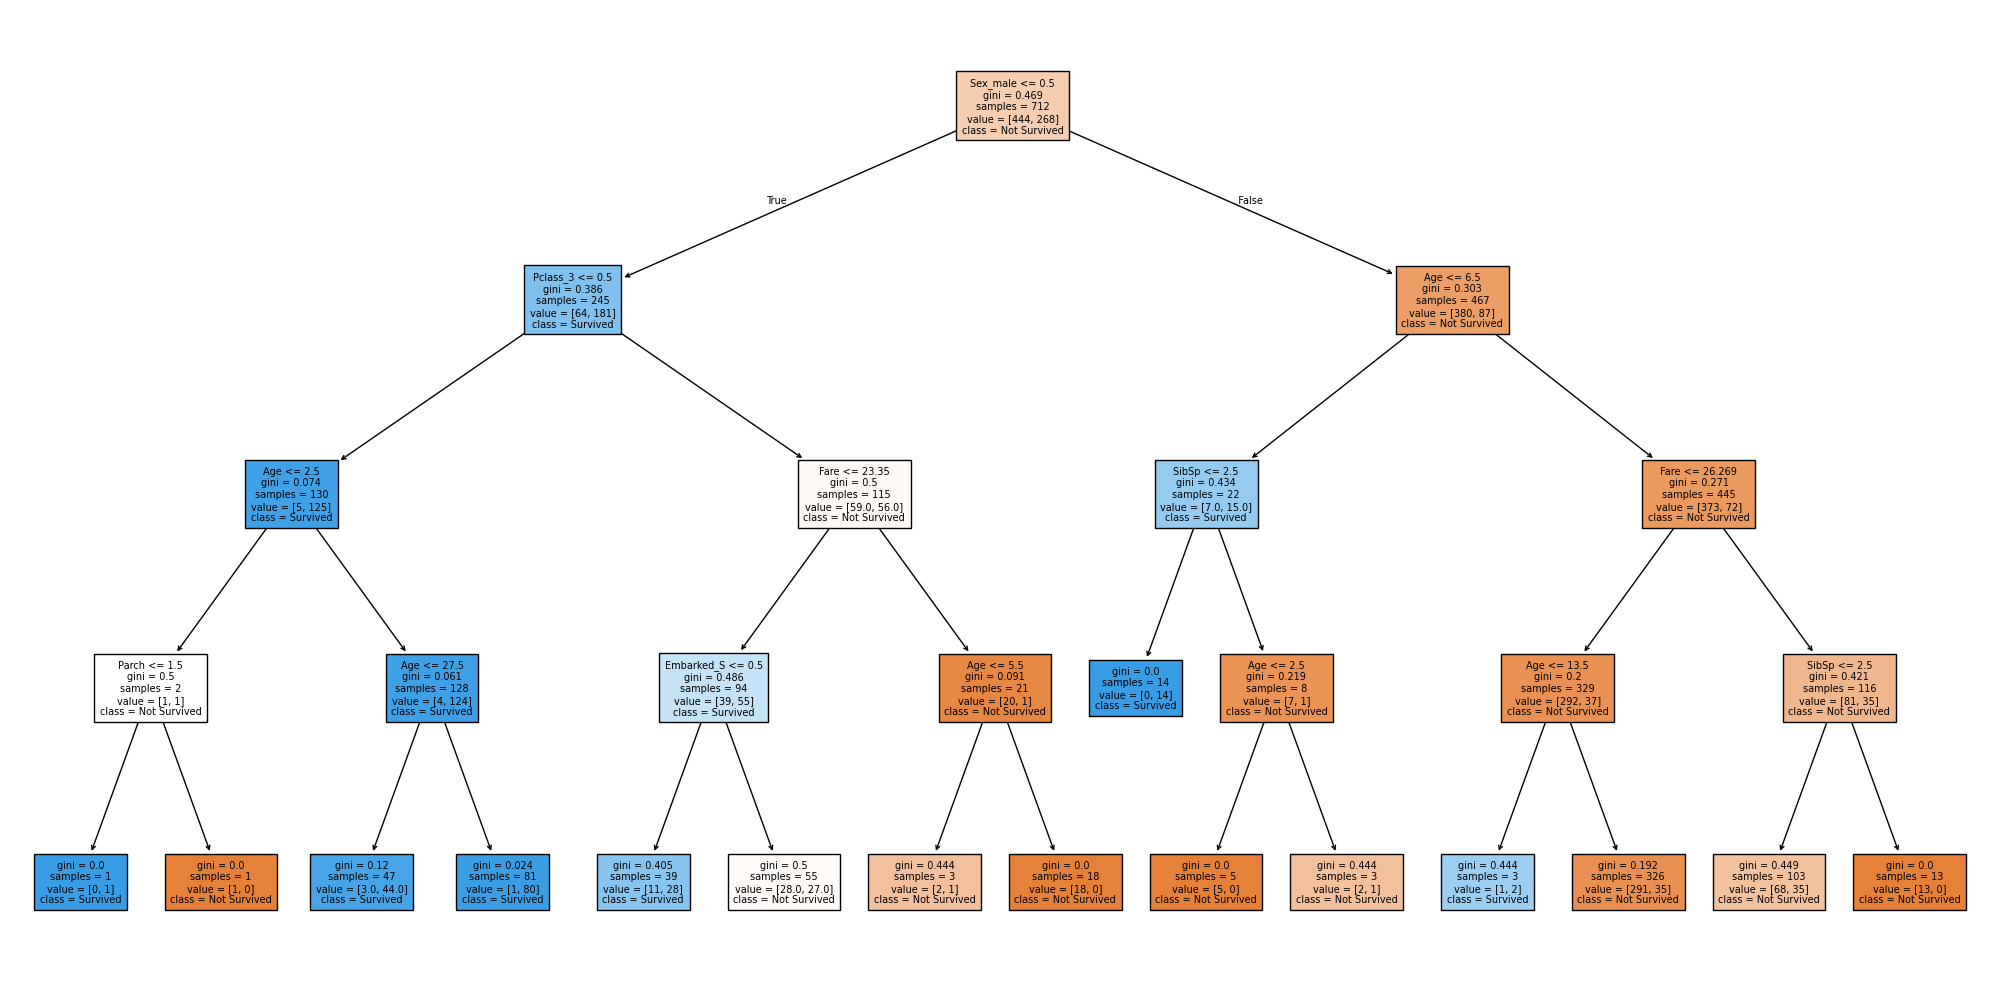

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# List of columns that will be one-hot encoded
categorical_cols_to_dummy = [
    'Sex', 'Embarked', 'Pclass'
]
# Target column
target_col = 'Survived'

# Convert potential numeric columns that might contain strings to numeric, coercing errors
for col in df.columns:
    if col not in categorical_cols_to_dummy and col != target_col:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values: median for numeric, mode for categorical/object
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_dummy, drop_first=True)

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")

In [ ]:
"""
Simple Random Forest Example
=============================
A small, easy-to-follow example: load a toy dataset, train a
Random Forest, check accuracy, OOB score, and feature importances.
"""

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# 1. Load the simple dataset
# ---------------------------------------------------------------------
df = pd.read_csv("train.csv")
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass'], drop_first=True)

print("Sample of the dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Class balance:\n{df['Survived'].value_counts()}")

TARGET = "Survived"
DROP_COLS = []  # nothing extra to drop, already handled above

feature_names = [c for c in df.columns if c not in [TARGET] + DROP_COLS]
X = df[feature_names].values
y = df[TARGET].values

# ---------------------------------------------------------------------
# 2. Train / test split
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ---------------------------------------------------------------------
# 3. Train a Random Forest
# ---------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 4. Evaluate
# ---------------------------------------------------------------------
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------------------
# 5. Feature importances
# ---------------------------------------------------------------------
print("Feature importances:")
for name, importance in sorted(
    zip(feature_names, rf.feature_importances_), key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
   Survived   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S  \
0         0  22.0      1      0   7.2500      True       False        True   
1         1  38.0      1      0  71.2833     False       False       False   
2         1  26.0      0      0   7.9250     False       False        True   
3         1  35.0      1      0  53.1000     False       False        True   
4         0  35.0      0      0   8.0500      True       False        True   

   Pclass_2  Pclass_3  
0     False      True  
1     False     False  
2     False      True  
3     False     False  
4     False      True  

Dataset shape: (891, 10)
Class balance:
Survived
0    549
1    342
Name: count, dtype: int64

OOB score: 0.7921
Test accuracy: 0.8101

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)